In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torch.optim as optim

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(512, 16, kernel_size=3, stride=1, padding=1)
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(512, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=Tr

In [3]:
IMG_HEIGHT = 512
IMG_WIDTH = 512
batch_size = 8

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder('casting_512x512/', transform=transform)

ok_class_idx = dataset.class_to_idx['ok_front']
def_class_idx = dataset.class_to_idx['def_front']

ok_indices = [i for i, label in enumerate(dataset.targets) if label == ok_class_idx]
def_indices = [i for i, label in enumerate(dataset.targets) if label == def_class_idx]

train_idx, val_idx = train_test_split(ok_indices, test_size=0.2, random_state=42)

train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False)
anomaly_loader = DataLoader(Subset(dataset, def_indices), batch_size=batch_size, shuffle=False)


Epoch [1/100] - loss: 0.1978 - val_loss: 0.1709
Epoch [2/100] - loss: 0.1349 - val_loss: 0.0960
Epoch [3/100] - loss: 0.0893 - val_loss: 0.0672
Epoch [4/100] - loss: 0.0616 - val_loss: 0.0534
Epoch [5/100] - loss: 0.0512 - val_loss: 0.0458
Epoch [6/100] - loss: 0.0469 - val_loss: 0.0459
Epoch [7/100] - loss: 0.0414 - val_loss: 0.0392
Epoch [8/100] - loss: 0.0387 - val_loss: 0.0370
Epoch [9/100] - loss: 0.0375 - val_loss: 0.0353
Epoch [10/100] - loss: 0.0355 - val_loss: 0.0426
Epoch [11/100] - loss: 0.0415 - val_loss: 0.0411
Epoch [12/100] - loss: 0.0392 - val_loss: 0.0399
Epoch [13/100] - loss: 0.0319 - val_loss: 0.0309
Epoch [14/100] - loss: 0.0310 - val_loss: 0.0310
Epoch [15/100] - loss: 0.0294 - val_loss: 0.0296
Epoch [16/100] - loss: 0.0284 - val_loss: 0.0291
Epoch [17/100] - loss: 0.0278 - val_loss: 0.0314
Epoch [18/100] - loss: 0.0274 - val_loss: 0.0300
Epoch [19/100] - loss: 0.0270 - val_loss: 0.0304
Epoch [20/100] - loss: 0.0270 - val_loss: 0.0277
Epoch [21/100] - loss: 0.0271

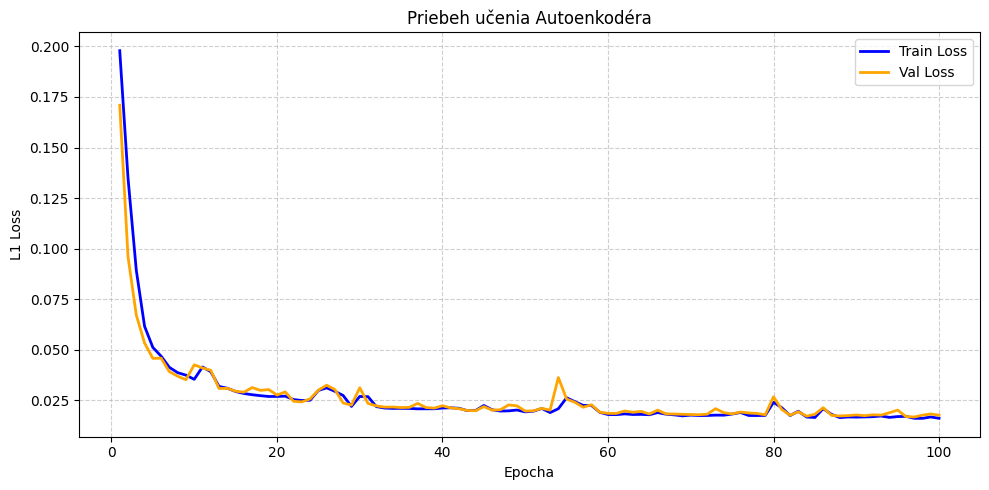

In [4]:
import matplotlib.pyplot as plt

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

history_train_loss = []
history_val_loss = []

for epoch in range(epochs):
    model.train() 
    train_loss = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad() 
        loss.backward()       
        optimizer.step()     
        
        train_loss += loss.item() * images.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    
    model.eval() 
    val_loss = 0.0
    
    with torch.no_grad(): 
        for images, _ in val_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)
            
            val_loss += loss.item() * images.size(0)
            
    val_loss = val_loss / len(val_loader.dataset)

    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), history_val_loss, label='Val Loss', color='orange', linewidth=2)

plt.title('Priebeh učenia Autoenkodéra')
plt.xlabel('Epocha')
plt.ylabel('L1 Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Reconstruction Quality Analysis (Per Image)


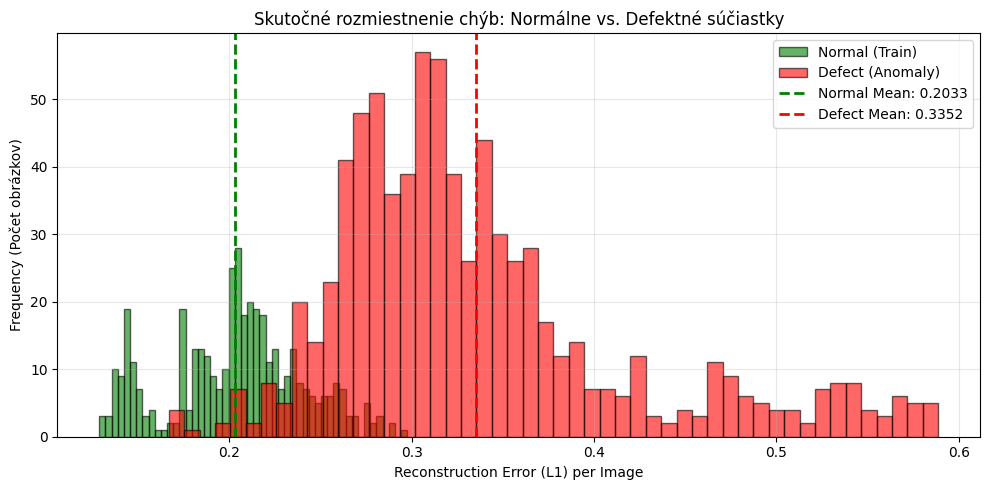

Normal Recon Error - Mean: 0.203289, Std: 0.036613
Defect Recon Error - Mean: 0.335192, Std: 0.082127
Separation Gap: 0.131902


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("Reconstruction Quality Analysis (Per Image)")

loss_fn = nn.L1Loss(reduction='none')

train_recon_errors = []
with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)
        reconstructions = model(images)
        mse_per_pixel = loss_fn(reconstructions, images)
        
        mse_flat = mse_per_pixel.view(images.size(0), -1)
        mse_per_image = torch.topk(mse_flat, k=2000, dim=1)[0].mean(dim=1)

        train_recon_errors.extend(mse_per_image.cpu().numpy())
train_recon_errors = np.array(train_recon_errors)

defect_recon_errors = []
with torch.no_grad():
    for images, _ in anomaly_loader:
        images = images.to(device)
        reconstructions = model(images)
        mse_per_pixel = loss_fn(reconstructions, images)
    
        mse_flat = mse_per_pixel.view(images.size(0), -1)
        mse_per_image = torch.topk(mse_flat, k=2000, dim=1)[0].mean(dim=1)

        defect_recon_errors.extend(mse_per_image.cpu().numpy())
defect_recon_errors = np.array(defect_recon_errors)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(train_recon_errors, bins=50, alpha=0.6, label='Normal (Train)', color='green', edgecolor='black')
ax.hist(defect_recon_errors, bins=50, alpha=0.6, label='Defect (Anomaly)', color='red', edgecolor='black')

ax.axvline(train_recon_errors.mean(), color='green', linestyle='--', linewidth=2, label=f'Normal Mean: {train_recon_errors.mean():.4f}')
ax.axvline(defect_recon_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Defect Mean: {defect_recon_errors.mean():.4f}')

ax.set_xlabel('Reconstruction Error (L1) per Image')
ax.set_ylabel('Frequency (Počet obrázkov)')
ax.set_title('Skutočné rozmiestnenie chýb: Normálne vs. Defektné súčiastky')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Normal Recon Error - Mean: {train_recon_errors.mean():.6f}, Std: {train_recon_errors.std():.6f}")
print(f"Defect Recon Error - Mean: {defect_recon_errors.mean():.6f}, Std: {defect_recon_errors.std():.6f}")
print(f"Separation Gap: {defect_recon_errors.mean() - train_recon_errors.mean():.6f}")

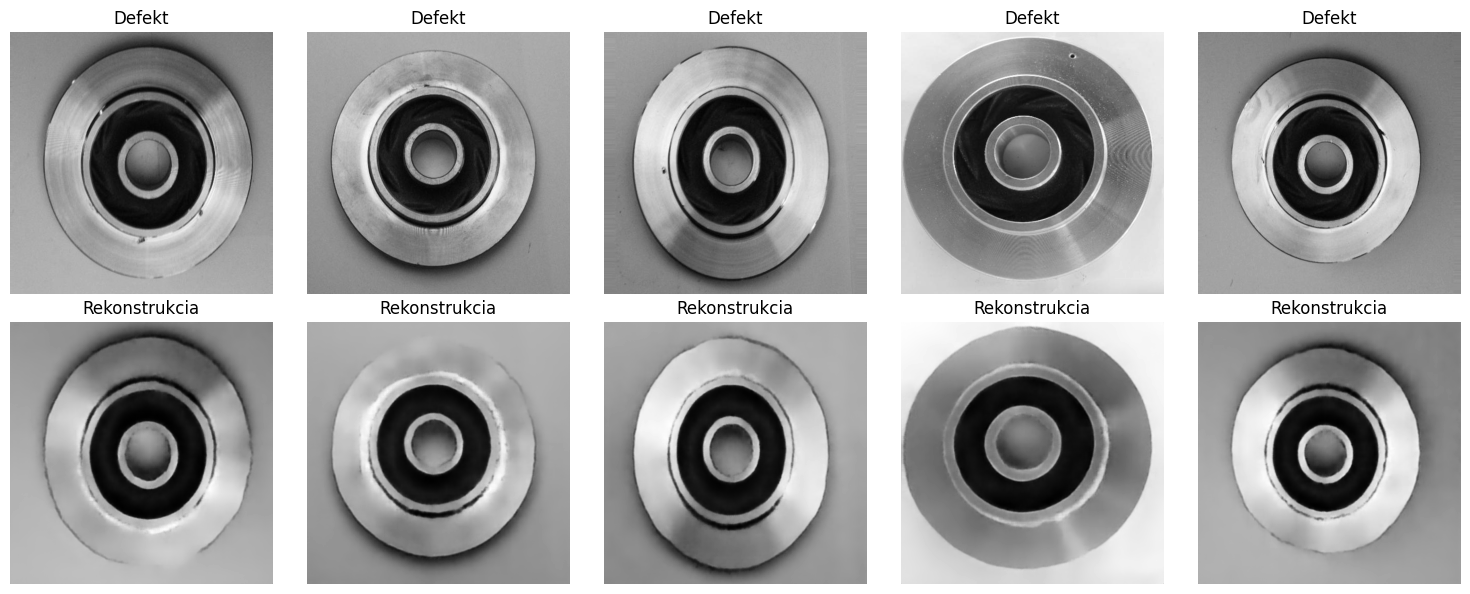

In [22]:
import random

model.eval()
subset_indices = anomaly_loader.dataset.indices
random_indices = random.sample(subset_indices, 5)

random_images = []
for idx in random_indices:
    img, _ = dataset[idx]
    random_images.append(img)

images = torch.stack(random_images).to(device)

with torch.no_grad():
    reconstructions = model(images)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Defekt")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Rekonstrukcia")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.neighbors import KernelDensity
import numpy as np

model.eval()
encoded_train_images = []

print("Extracting features for KDE...")
with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device)
        
        latent = model.encoder(images)
        
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        encoded_train_images.append(latent_flat)

encoded_train_images = np.concatenate(encoded_train_images, axis=0)

print("Fitting KDE...")
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(encoded_train_images)
print("KDE Fit Complete!")

Extracting features for KDE...
Fitting KDE...
KDE Fit Complete!


--- VYHODNOTENIE MODELU ---
Defektné súčiastky: 50/50 správne identifikované (100.0%)
Normálne súčiastky: 38/50 správne identifikované (76.0%)
-----------------------------------
CELKOVÁ ÚSPEŠNOSŤ (Presnosť): 88.0%

Generujem vizuálnu ukážku...


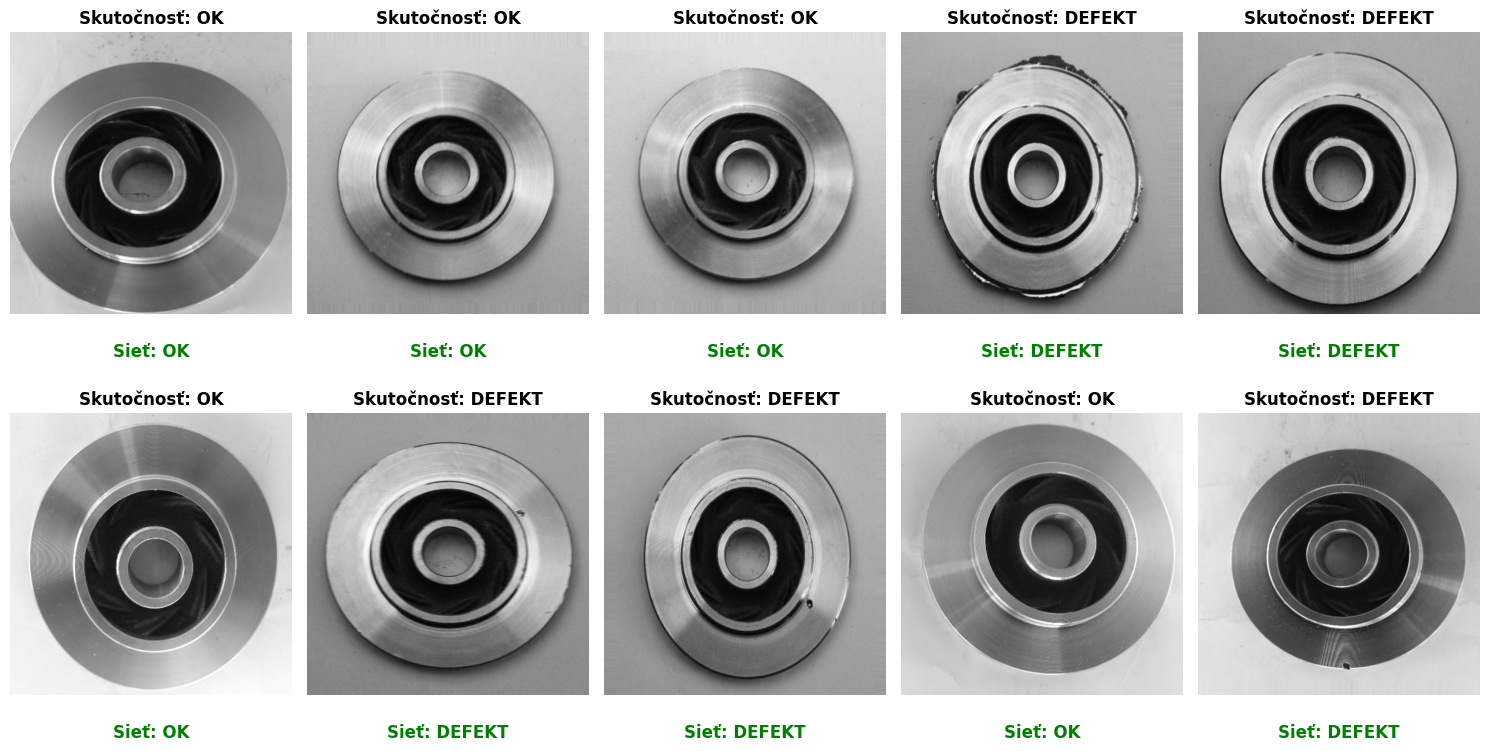

In [33]:
import random
import glob
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch
import torch.nn as nn

RECON_THRESH = 0.19    
DENSITY_THRESH = -150

def evaluate_batch(paths, expected_anomaly=True):
    correct = 0
    total = min(50, len(paths))
    sampled_paths = random.sample(paths, total)
    
    for img_path in sampled_paths:
        img = Image.open(img_path).convert('L')
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            reconstruction = model(img_tensor)
            recon_error = nn.L1Loss()(reconstruction, img_tensor).item()
            
            latent = model.encoder(img_tensor)
            latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
            density = kde.score_samples(latent_flat)[0]
        
        is_anomaly = (density < DENSITY_THRESH or recon_error > RECON_THRESH)
        
        if is_anomaly == expected_anomaly:
            correct += 1
            
    return correct, total

anomaly_paths = glob.glob('casting_512x512/def_front/*')
normal_paths = glob.glob('casting_512x512/ok_front/*')

print("--- VYHODNOTENIE MODELU ---")
def_corr, def_tot = evaluate_batch(anomaly_paths, expected_anomaly=True)
def_acc = (def_corr / def_tot) * 100

ok_corr, ok_tot = evaluate_batch(normal_paths, expected_anomaly=False)
ok_acc = (ok_corr / ok_tot) * 100

print(f"Defektné súčiastky: {def_corr}/{def_tot} správne identifikované ({def_acc:.1f}%)")
print(f"Normálne súčiastky: {ok_corr}/{ok_tot} správne identifikované ({ok_acc:.1f}%)")
print("-" * 35)
total_acc = ((def_corr + ok_corr) / (def_tot + ok_tot)) * 100
print(f"CELKOVÁ ÚSPEŠNOSŤ (Presnosť): {total_acc:.1f}%\n")

print("Generujem vizuálnu ukážku...")

demo_paths = random.sample(anomaly_paths, 5) + random.sample(normal_paths, 5)
random.shuffle(demo_paths)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

for i, img_path in enumerate(demo_paths):
    row = i // 5
    col = i % 5
    
    is_really_anomaly = 'def_front' in img_path
    real_label = "DEFEKT" if is_really_anomaly else "OK"
    
    img = Image.open(img_path).convert('L')
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        reconstruction = model(img_tensor)
        recon_error = nn.L1Loss()(reconstruction, img_tensor).item()
        
        latent = model.encoder(img_tensor)
        latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
        density = kde.score_samples(latent_flat)[0]
        
    is_predicted_anomaly = (density < DENSITY_THRESH or recon_error > RECON_THRESH)
    pred_label = "DEFEKT" if is_predicted_anomaly else "OK"
    
    text_color = 'green' if is_predicted_anomaly == is_really_anomaly else 'red'

    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"Skutočnosť: {real_label}", fontweight='bold')
    
    axes[row, col].text(0.5, -0.15, f"Sieť: {pred_label}", 
                 fontsize=12, color=text_color, ha='center', transform=axes[row, col].transAxes, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()